In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Pytorch-Models/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models


In [3]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/markerpensseg/train/")
count_images("datasets/markerpensseg/valid")

Total images: 225
Total images: 30


In [ ]:
# STEP 1: Install compatible PyTorch (2.0.1 + CUDA 11.7)
!pip install torch==2.0.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# STEP 2: Install OpenMMLab tools
!pip install -U openmim
!mim install "mmengine>=0.7.4"
!mim install "mmcv==2.1.0"

# STEP 3: Clone MMDetection & install
!git clone https://github.com/open-mmlab/mmdetection.git
%cd mmdetection
!pip install -e .

In [2]:
# STEP 4: Final check
!python -c "import torch; import mmcv; import mmdet; print('PyTorch:', torch.__version__); print('MMCV:', mmcv.__version__); print('MMDet:', mmdet.__version__)"

PyTorch: 2.0.1+cu117
MMCV: 2.1.0
MMDet: 3.3.0


In [ ]:
!git clone https://github.com/open-mmlab/mmdeploy.git
%cd mmdeploy
!pip install -e .

In [3]:
!python -c "import mmdeploy; print('MMDeploy:', mmdeploy.__version__)"

MMDeploy: 1.3.1


In [ ]:
!pip install numpy==1.24.4

In [2]:
!ls mmdetection/projects/ViTDet/configs/

lsj-100e_coco-instance.py   vitdet_mask-rcnn_vit-b-mae_lsj-100e.py
vitdet_maskrcnn_markers.py


In [10]:
custom_cfg = """
_base_ = 'vitdet_mask-rcnn_vit-b-mae_lsj-100e.py'

# Custom classes
dataset_type = 'CocoDataset'
metainfo = dict(classes=("CAP",))
num_classes = 1
image_size = (512, 512)

backbone_norm_cfg = dict(type='LN', requires_grad=True)
norm_cfg = dict(type='LN2d', requires_grad=True)

vis_backends = [
    dict(type='LocalVisBackend'), # no Tensorboard backend
]
visualizer = dict(
    type='DetLocalVisualizer', vis_backends=vis_backends, name='visualizer')

# Paths
data_root = '/content/gdrive/MyDrive/Pytorch-Models/datasets/'
train_ann = data_root + 'markerpensseg/train/_annotations.coco.json'
val_ann = data_root + 'markerpensseg/valid/_annotations.coco.json'
train_img = data_root + 'markerpensseg/train/'
val_img = data_root + 'markerpensseg/valid/'

# Pipelines
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='Resize', scale=(512, 512), keep_ratio=False),
    dict(type='RandomFlip', prob=0.5),
    dict(type='Pad', size=(512, 512), pad_val=dict(img=(114, 114, 114))),
    dict(type='PackDetInputs')
]

test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='Resize', scale=(512, 512), keep_ratio=False),
    dict(type='Pad', size=(512, 512), pad_val=dict(img=(114, 114, 114))),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='PackDetInputs', meta_keys=('img_id', 'img_path', 'ori_shape', 'img_shape', 'scale_factor'))
]

# Data loader
train_dataloader = dict(
    batch_size=1,
    num_workers=1,
    dataset=dict(
        _delete_=True,
        type=dataset_type,
        data_root=data_root,
        ann_file=train_ann,
        data_prefix=dict(img=train_img),
        filter_cfg=dict(filter_empty_gt=True, min_size=32),
        pipeline=train_pipeline,
        metainfo=dict(classes=("CAP",)),
    )
)

val_dataloader = dict(
    batch_size=1,
    num_workers=1,
    dataset=dict(
        _delete_=True,
        type=dataset_type,
        data_root=data_root,
        ann_file=val_ann,
        data_prefix=dict(img=val_img),
        pipeline=test_pipeline,
        test_mode=True,
        metainfo=dict(classes=("CAP",)),
    )
)

test_dataloader = val_dataloader

# Evaluator
val_evaluator = dict(type='CocoMetric', ann_file=val_ann, metric=['bbox', 'segm'])
# val_evaluator = dict(type='CocoMetric', ann_file=val_ann, metric=['bbox', 'segm'], classwise=True)
test_evaluator = val_evaluator

# Model
model = dict(
    backbone=dict(
        _delete_=True,
        type='ViT',
        img_size=512,
        patch_size=16,
        embed_dim=768,
        depth=12,
        num_heads=12,
        drop_path_rate=0.1,
        window_size=14,
        mlp_ratio=4,
        qkv_bias=True,
        norm_cfg=backbone_norm_cfg,
        window_block_indexes=[
            0,
            1,
            3,
            4,
            6,
            7,
            9,
            10,
        ],
        use_rel_pos=True,
        init_cfg=None),
    neck=dict(
        _delete_=True,
        type='SimpleFPN',
        backbone_channel=768,
        in_channels=[192, 384, 768, 768],
        out_channels=256,
        num_outs=5,
        norm_cfg=norm_cfg),
    rpn_head=dict(num_convs=2),
    roi_head=dict(
        bbox_head=dict(
            type='Shared4Conv1FCBBoxHead',
            num_classes=num_classes,
            conv_out_channels=256,
            norm_cfg=norm_cfg),
        mask_head=dict(num_classes=num_classes, norm_cfg=norm_cfg)))

# Schedule
max_iters = 2250
interval = 225
dynamic_intervals = [(max_iters // interval * interval + 1, max_iters)]
train_cfg = dict(
    type='IterBasedTrainLoop',
    max_iters=max_iters,
    val_interval=interval,
    dynamic_intervals=dynamic_intervals)
val_cfg = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

# Optimizer
optim_wrapper = dict(
    type='AmpOptimWrapper',
    constructor='LayerDecayOptimizerConstructor',
    paramwise_cfg={
        'decay_rate': 0.7,
        'decay_type': 'layer_wise',
        'num_layers': 12,
    },
    optimizer=dict(
        type='AdamW',
        lr=0.0001,
        betas=(0.9, 0.999),
        weight_decay=0.1,
    ))

# Learning policy
param_scheduler = [
    dict(type='LinearLR', start_factor=0.001, by_epoch=False, begin=0, end=60),
    dict(
        type='MultiStepLR',
        begin=0,
        end=10,
        by_epoch=True,
        milestones=[7, 9],
        gamma=0.1
    )
]

# Logging and checkpointing
default_hooks = dict(
    logger=dict(type='LoggerHook', interval=450),
    checkpoint=dict(type='CheckpointHook', interval=450)
)

# Output path
work_dir = '/content/gdrive/MyDrive/Pytorch-Models/mmdetection/mmdet_outputs/vitdet_maskrcnn_markers'

# Load pretrained COCO model
load_from = 'https://download.openmmlab.com/mmdetection/v3.0/vitdet/vitdet_mask-rcnn_vit-b-mae_lsj-100e/vitdet_mask-rcnn_vit-b-mae_lsj-100e_20230328_153519-e15fe294.pth'
"""

with open('mmdetection/projects/ViTDet/configs/vitdet_maskrcnn_markers.py', 'w') as f:
    f.write(custom_cfg)

In [11]:
!python mmdetection/tools/train.py mmdetection/projects/ViTDet/configs/vitdet_maskrcnn_markers.py --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/28 10:36:39 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 767977029
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA R

In [12]:
!python mmdetection/tools/test.py mmdetection/projects/ViTDet/configs/vitdet_maskrcnn_markers.py mmdetection/mmdet_outputs/vitdet_maskrcnn_markers/iter_2250.pth

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/28 11:14:32 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 2067409989
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA 

In [13]:
from mmdet.apis import init_detector, inference_detector
import mmcv

# Config and checkpoint paths
config_file = 'mmdetection/projects/ViTDet/configs/vitdet_maskrcnn_markers.py'
checkpoint_file = 'mmdetection/mmdet_outputs/vitdet_maskrcnn_markers/iter_2250.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

# Image path
img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'

# Run inference
result = inference_detector(model, img)
print(result)

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117


Loads checkpoint by local backend from path: mmdetection/mmdet_outputs/vitdet_maskrcnn_markers/iter_2250.pth
<DetDataSample(

    META INFORMATION
    ori_shape: (2048, 1536)
    batch_input_shape: (512, 512)
    img_shape: (512, 512)
    img_id: 0
    img_path: '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'
    pad_shape: (512, 512)
    scale_factor: (0.3333333333333333, 0.25)

    DATA FIELDS
    gt_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            labels: tensor([], device='cuda:0', dtype=torch.int64)
            masks: BitmapMasks(num_masks=0, height=2048, width=1536)
            bboxes: tensor([], device='cuda:0', size=(0, 4))
        ) at 0x7a8abb0c9650>
    ignored_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            labels: tensor([], device='cuda:0', dtype=torc

Loads checkpoint by local backend from path: mmdetection/mmdet_outputs/vitdet_maskrcnn_markers/iter_2250.pth


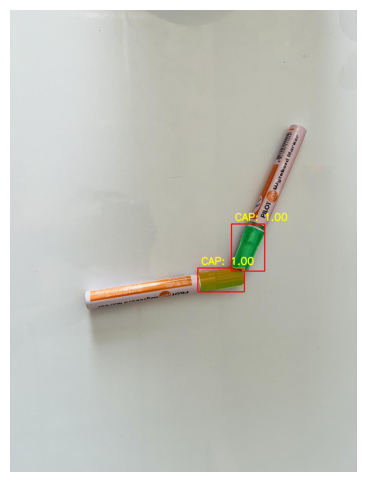

In [14]:
from mmdet.apis import init_detector, inference_detector
import mmcv
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import random

# Class labels
CLASS_LABELS = ["CAP"]

PRED_COLORS = {0: (0, 255, 0)}

# Config and checkpoint paths
config_file = 'mmdetection/projects/ViTDet/configs/vitdet_maskrcnn_markers.py'
checkpoint_file = 'mmdetection/mmdet_outputs/vitdet_maskrcnn_markers/iter_2250.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

def draw_bbox_with_label(img, bbox, label, score, color=(0, 0, 255), thickness=3):
    xmin, ymin, xmax, ymax = map(int, bbox)
    # Draw rectangle
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, thickness)
    # Put label text
    cv2.putText(
        img, f"{label}: {score:.2f}", (xmin + 15, ymin - 15),
        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 3, cv2.LINE_AA
    )

# Image path
img_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'
img = cv2.imread(img_path)
if img is None:
    raise Exception("Image not found or unreadable")

# Run inference
results = inference_detector(model, img_path)

# Access the prediction results from the DetDataSample object
pred_instances = results.pred_instances

CONF_THRESHOLD = 0.3
img_with_masks = img.copy()

# Draw boxes and labels
# pred_instances.bboxes, pred_instances.scores, and pred_instances.labels are tensors
for i in range(len(pred_instances.bboxes)):
    score = pred_instances.scores[i]
    if score < CONF_THRESHOLD:
        continue

    # 1. Get Class and Color
    label_id = pred_instances.labels[i].item()
    class_name = CLASS_LABELS[label_id]
    color = PRED_COLORS[label_id]

    # 2. Extract and Process Mask
    # pred_instances.masks is a boolean tensor of shape (N, H, W)
    mask = pred_instances.masks[i].cpu().numpy()

    # Create a colored version of the mask
    colored_mask = np.zeros_like(img, dtype=np.uint8)
    colored_mask[mask] = color

    # 3. Overlay Mask onto Image (Alpha Blending)
    alpha = 0.4  # Transparency level
    img_with_masks = cv2.addWeighted(img_with_masks, 1.0, colored_mask, alpha, 0)

    # 4. Draw Bounding Box and Label
    bbox = pred_instances.bboxes[i].tolist()
    draw_bbox_with_label(img_with_masks, bbox, class_name, score, color=(0, 0, 255))

# Show result
img_with_bbox_rgb = cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img_with_bbox_rgb)
plt.show()

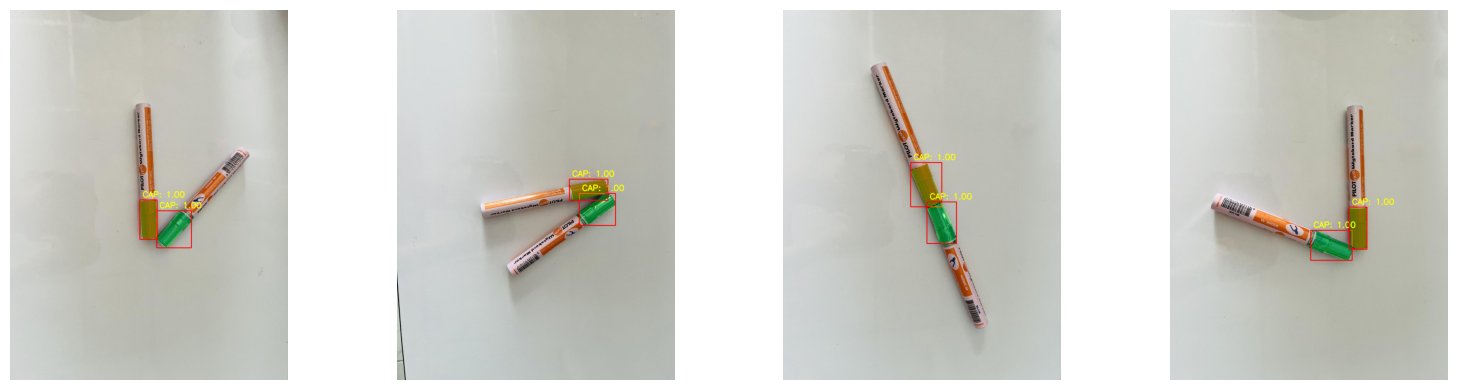

In [15]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(1, 4, ii+1)

    img = cv2.imread(image)

    results = inference_detector(model, image)

    # Access the prediction results from the DetDataSample object
    pred_instances = results.pred_instances

    CONF_THRESHOLD = 0.3
    img_with_masks = img.copy()

    # Draw boxes and labels
    # pred_instances.bboxes, pred_instances.scores, and pred_instances.labels are tensors
    for i in range(len(pred_instances.bboxes)):
        score = pred_instances.scores[i]
        if score < CONF_THRESHOLD:
            continue

        # 1. Get Class and Color
        label_id = pred_instances.labels[i].item()
        class_name = CLASS_LABELS[label_id]
        color = PRED_COLORS[label_id]

        # 2. Extract and Process Mask
        # pred_instances.masks is a boolean tensor of shape (N, H, W)
        mask = pred_instances.masks[i].cpu().numpy()

        # Create a colored version of the mask
        colored_mask = np.zeros_like(img, dtype=np.uint8)
        colored_mask[mask] = color

        # 3. Overlay Mask onto Image (Alpha Blending)
        alpha = 0.4  # Transparency level
        img_with_masks = cv2.addWeighted(img_with_masks, 1.0, colored_mask, alpha, 0)

        # 4. Draw Bounding Box and Label
        bbox = pred_instances.bboxes[i].tolist()
        draw_bbox_with_label(img_with_masks, bbox, class_name, score, color=(0, 0, 255))

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 126.9 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!

In [17]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 7.8 MB/s eta 0:00:00


In [19]:
!python mmdeploy/tools/deploy.py \
    mmdeploy/configs/mmdet/instance-seg/instance-seg_onnxruntime_static.py \
    mmdetection/projects/ViTDet/configs/vitdet_maskrcnn_markers.py \
    mmdetection/mmdet_outputs/vitdet_maskrcnn_markers/iter_2250.pth \
    /content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg \
    --work-dir mmdeploy/mmdeploy_output/vitdet_maskrcnn_markers/ \
    --device cpu \
    --dump-info

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/28 11:52:40 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "Codebases" registry tree. As a workaround, the current "Codebases" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
02/28 11:52:40 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "mmdet_tasks" registry tree. As a workaround, the current "mmdet_tasks" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/28 11:52:45 - mmengine - INFO - Start pipe

In [21]:
%ls mmdeploy/mmdeploy_output/vitdet_maskrcnn_markers/

deploy.json  end2end.onnx            output_pytorch.jpg
detail.json  output_onnxruntime.jpg  pipeline.json


In [22]:
import onnxruntime
import numpy as np
import cv2
import torch

# Load image and preprocess
img_path = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg"

mean = np.array([123.675, 116.28, 103.53], dtype=np.float32)
std = np.array([58.395, 57.12, 57.375], dtype=np.float32)

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (512, 512))
img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("mmdeploy/mmdeploy_output/vitdet_maskrcnn_markers/end2end.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(1, 3, 5), (1, 3), (1, 3, 28, 28)]


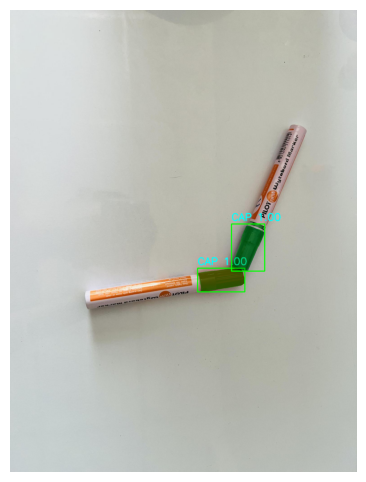

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

CLASS_LABELS = ['CAP']

# 1. Unpack outputs
# (1, 3, 5) -> boxes and scores
# (1, 3) -> labels
# (1, 3, 28, 28) -> raw mask logits
dets, labels, mask_logits = outputs[0][0], outputs[1][0], outputs[2][0]

orig_h, orig_w = img.shape[:2]
img_with_bbox = img.copy()

for i in range(len(dets)):
    box = dets[i, :4]
    score = dets[i, 4]
    label = int(labels[i])
    labeltext = CLASS_LABELS[label]

    if score < 0.5: # Threshold
        continue

    # --- Step A: Scale Box to Original Image ---
    x1 = int(box[0] * orig_w / 512)
    y1 = int(box[1] * orig_h / 512)
    x2 = int(box[2] * orig_w / 512)
    y2 = int(box[3] * orig_h / 512)

    # Clip coordinates to image boundaries
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(orig_w, x2), min(orig_h, y2)

    # --- Step B: Process the Mask ---
    # 1. Get the 28x28 mask for this object
    mask = mask_logits[i]

    # 2. Resize mask from 28x28 to the size of the bounding box
    box_w, box_h = x2 - x1, y2 - y1
    if box_w > 0 and box_h > 0:
        mask_resized = cv2.resize(mask, (box_w, box_h))

        # 3. Threshold the mask (0.5 is standard)
        mask_binary = (mask_resized > 0.5).astype(np.uint8)

        # 4. Create a random color for this mask
        # color = np.random.randint(0, 255, (3,)).tolist()
        color = (0, 255, 0)

        # 5. Apply the mask as an overlay
        roi = img_with_bbox[y1:y2, x1:x2]
        # Paint the mask pixels
        roi[mask_binary == 1] = roi[mask_binary == 1] * 0.5 + np.array(color) * 0.3
        img_with_bbox[y1:y2, x1:x2] = roi

    # --- Step C: Draw Bounding Box and Label ---
    cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(img_with_bbox, f"{labeltext} {score:.2f}", (x1, y1 - 15),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

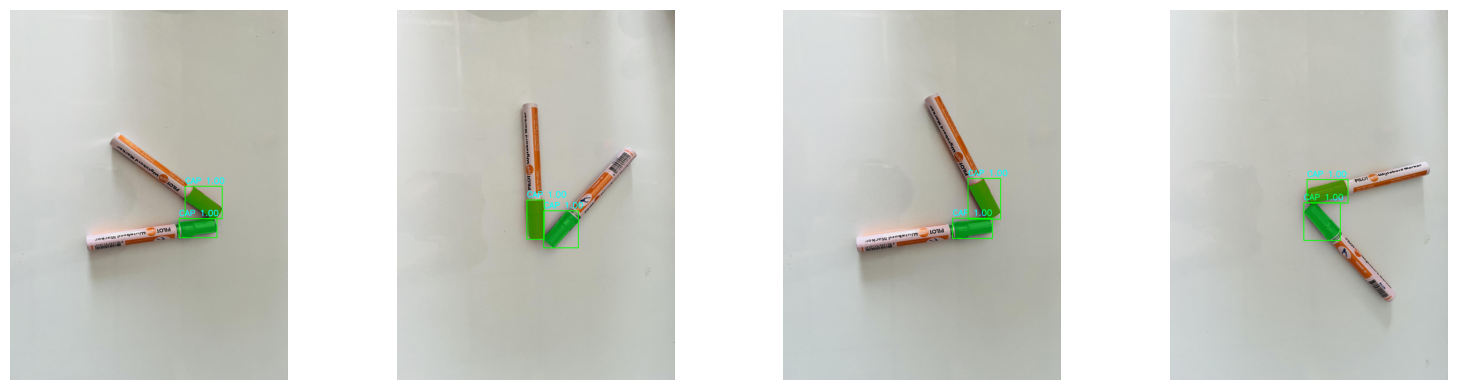

In [25]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

CLASS_LABELS = ['CAP']

session = onnxruntime.InferenceSession("mmdeploy/mmdeploy_output/vitdet_maskrcnn_markers/end2end.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(1, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (512, 512))
    img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    dets, labels, mask_logits = outputs[0][0], outputs[1][0], outputs[2][0]

    orig_h, orig_w = img.shape[:2]
    img_with_bbox = img.copy()

    for i in range(len(dets)):
        box = dets[i, :4]
        score = dets[i, 4]
        label = int(labels[i])
        labeltext = CLASS_LABELS[label]

        if score < 0.5: # Threshold
            continue

        # --- Step A: Scale Box to Original Image ---
        x1 = int(box[0] * orig_w / 512)
        y1 = int(box[1] * orig_h / 512)
        x2 = int(box[2] * orig_w / 512)
        y2 = int(box[3] * orig_h / 512)

        # Clip coordinates to image boundaries
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(orig_w, x2), min(orig_h, y2)

        # --- Step B: Process the Mask ---
        # 1. Get the 28x28 mask for this object
        mask = mask_logits[i]

        # 2. Resize mask from 28x28 to the size of the bounding box
        box_w, box_h = x2 - x1, y2 - y1
        if box_w > 0 and box_h > 0:
            mask_resized = cv2.resize(mask, (box_w, box_h))

            # 3. Threshold the mask (0.5 is standard)
            mask_binary = (mask_resized > 0.5).astype(np.uint8)

            # 4. Create a random color for this mask
            # color = np.random.randint(0, 255, (3,)).tolist()
            color = (0, 255, 0)

            # 5. Apply the mask as an overlay
            roi = img_with_bbox[y1:y2, x1:x2]
            # Paint the mask pixels
            roi[mask_binary == 1] = roi[mask_binary == 1] * 0.5 + np.array(color) * 0.5
            img_with_bbox[y1:y2, x1:x2] = roi

        # --- Step C: Draw Bounding Box and Label ---
        cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(img_with_bbox, f"{labeltext} {score:.2f}", (x1, y1 - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()